## Phase 2 : Analyse Exploratoire des Données (EDA)

### Objectif de cette phase

L'Analyse Exploratoire des Données (EDA) constitue une étape fondamentale du cycle de vie d'un projet Machine Learning. Elle permet de :
- **Comprendre la distribution** de chaque variable et détecter les anomalies
- **Identifier les relations** entre les features et la variable cible
- **Valider les hypothèses métier** sur le chômage des diplômés tunisiens
- **Orienter les choix** de preprocessing et de feature engineering (Phase 3)

Dans cette phase, nous analysons les données corrigées de l'ENPE 2017 avec les vrais codes INS confirmés :
- `V_0_244_i` : **1=Chômeur**, **2=Employé**, **3=Inactif**, 4=Moins de 15 ans (exclus), 9=Non déclaré (exclus)
- `V_1_204_i` : **1=Masculin**, **2=Féminin**
- `V_1_225_i` : **1=Sans diplôme**, **2=Enseignement de base**, **3=Secondaire**, **4=Supérieur**


In [1]:
# ── CELLULE 0 : Connexion Google Drive ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# Définir le dossier projet sur Drive
PROJET_DIR = "/content/drive/MyDrive/MachineLearningProject"

# Créer les sous-dossiers si nécessaire
os.makedirs(f"{PROJET_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{PROJET_DIR}/data",      exist_ok=True)
os.makedirs(f"{PROJET_DIR}/models",    exist_ok=True)

# Se placer dans le dossier projet
os.chdir(PROJET_DIR)

print(f"✅ Drive monté")
print(f"✅ Dossier actuel : {os.getcwd()}")
print(f"✅ Fichiers disponibles :")
for f in sorted(os.listdir(PROJET_DIR)):
    print(f"   → {f}")

Mounted at /content/drive
✅ Drive monté
✅ Dossier actuel : /content/drive/MyDrive/MachineLearningProject
✅ Fichiers disponibles :
   → Amelioration_Tentative
   → Data
   → ENPE_2017.csv
   → README.md
   → data
   → graph
   → models
   → notebooks
   → requirements.txt
   → src


---
## 1. Importation des Librairies et Chargement des Données

Nous rechargeons le dataset sauvegardé en Phase 1 au format CSV pour éviter de relire le fichier SAS.
Les librairies utilisées sont :
- **pandas / numpy** : manipulation des données
- **matplotlib / seaborn** : visualisations graphiques
- **warnings** : suppression des avertissements non critiques


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})

# Chargement du CSV sauvegardé en Phase 1
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MachineLearningProject/notebooks/ENPE_2017.csv")

print(f"✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")


✅ Dataset chargé : 452,928 lignes × 20 colonnes


---
## 2. Préparation de la Variable Cible

Avant toute analyse, nous filtrons les individus non pertinents et créons la variable cible correcte.

**Codes confirmés par diagnostic :**

| Code V_0_244_i | Signification | Action |
|---|---|---|
| 1 | Chômeur | ✅ Conservé |
| 2 | Employé | ✅ Conservé |
| 3 | Inactif (femmes au foyer, retraités...) | ✅ Conservé |
| 4 | Moins de 15 ans | ❌ Exclu |
| 9 | Non déclaré | ❌ Exclu |

> **Note :** L'inactif en Tunisie représente souvent une femme diplômée qui a abandonné la recherche d'emploi face aux difficultés du marché — c'est une réalité socio-économique importante que notre modèle devra capturer.


In [3]:
# Filtrer codes invalides (4 = moins de 15 ans, 9 = non déclaré)
df_eda = df[df["V_0_244_i"].isin([1, 2, 3])].copy()

# Filtrer âge incohérent
df_eda = df_eda[df_eda["V_210tr"] >= 15].copy()

# Créer la variable cible lisible
STATUT = {1: "Chômeur", 2: "Employé", 3: "Inactif"}
df_eda["statut"] = df_eda["V_0_244_i"].map(STATUT)

COLORS = {"Chômeur": "#E24B4A", "Employé": "#1D9E75", "Inactif": "#888780"}

print(f"Dataset après filtrage : {len(df_eda):,} individus")
print(f"Exclus                 : {len(df) - len(df_eda):,} individus (codes 4 et 9, âge < 15)")
print(f"\nDistribution de la variable cible :")
for statut, count in df_eda["statut"].value_counts().items():
    pct = count / len(df_eda) * 100
    print(f"  {statut:<12} : {count:>8,}  ({pct:5.1f}%)")


Dataset après filtrage : 295,411 individus
Exclus                 : 157,517 individus (codes 4 et 9, âge < 15)

Distribution de la variable cible :
  Inactif      :  129,993  ( 44.0%)
  Employé      :   96,198  ( 32.6%)
  Chômeur      :   69,220  ( 23.4%)


---
## 3. Distribution de la Variable Cible

Cette visualisation montre la répartition des trois classes dans notre dataset filtré.

**Déséquilibre attendu :** Le dataset présente un déséquilibre naturel entre les classes car la population tunisienne comporte davantage d'inactifs (femmes au foyer, retraités, étudiants) que de chômeurs ou d'employés dans la tranche 15–75 ans.

> Cette observation justifiera l'utilisation de **SMOTE** en Phase 3 pour équilibrer les classes avant la modélisation.


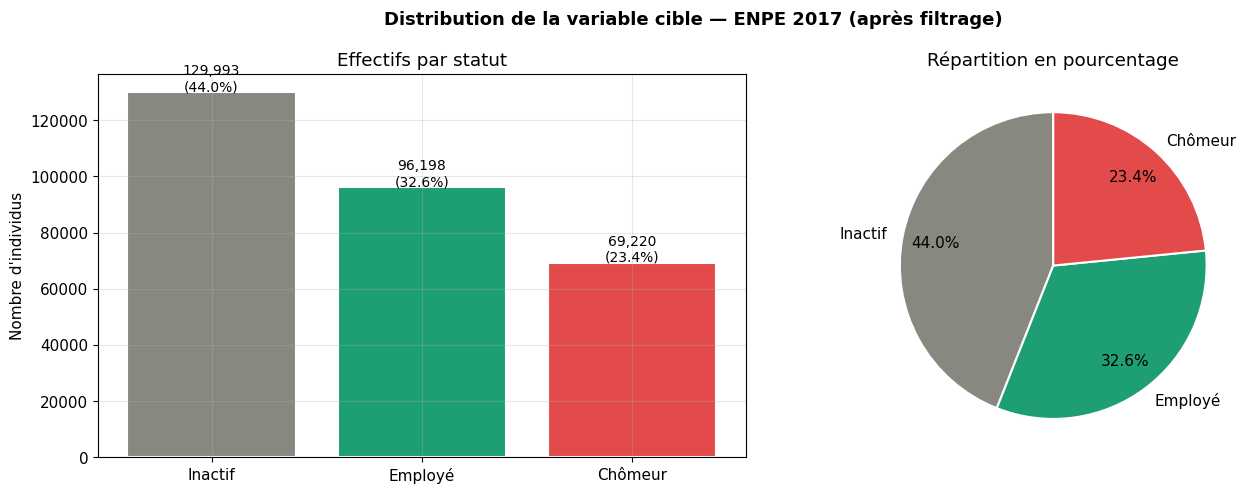

✅ eda1_distribution_cible.png


In [4]:
cible_counts = df_eda["statut"].value_counts()
noms   = cible_counts.index.tolist()
colors = [COLORS[n] for n in noms]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de la variable cible — ENPE 2017 (après filtrage)",
             fontsize=13, fontweight="bold")

# Barplot
bars = axes[0].bar(noms, cible_counts.values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Effectifs par statut")
axes[0].set_ylabel("Nombre d'individus")
for bar, val in zip(bars, cible_counts.values):
    pct = val / len(df_eda) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=10)

# Pie chart
axes[1].pie(cible_counts.values, labels=noms, colors=colors,
            autopct="%1.1f%%", startangle=90, pctdistance=0.78,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.savefig("eda1_distribution_cible.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ eda1_distribution_cible.png")


---
## 4. Analyse du Chômage par Gouvernorat

La Tunisie présente de fortes disparités régionales en matière d'emploi. Les gouvernorats de l'intérieur (Kasserine, Gafsa, Sidi Bouzid, Kef, Siliana) souffrent historiquement d'un taux de chômage plus élevé que les régions côtières (Tunis, Sousse, Sfax).

**Formule du taux de chômage :**
```
Taux chômage = Chômeurs / (Chômeurs + Employés) × 100
```
> L'inactif est exclu du calcul car il ne cherche pas d'emploi et n'est donc pas comptabilisé dans la population active.


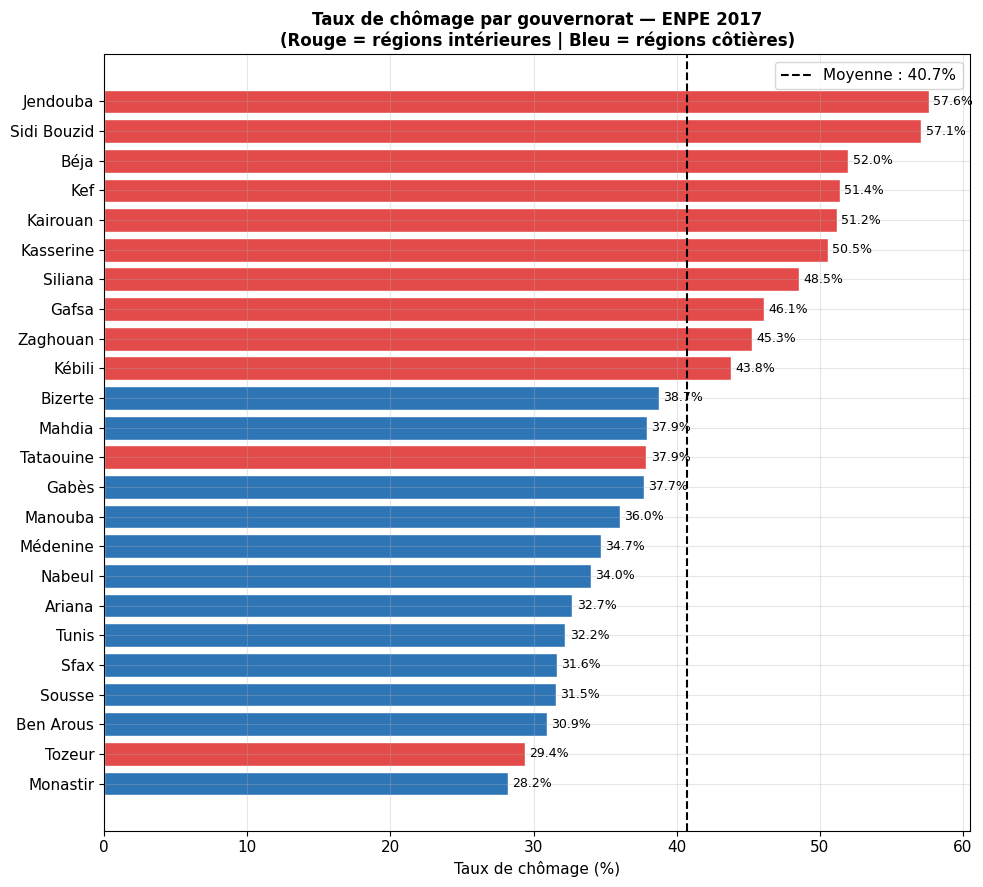

✅ eda2_chomage_gouvernorat.png


In [5]:
GOUV = {
    11:"Tunis", 12:"Ariana", 13:"Ben Arous", 14:"Manouba",
    15:"Nabeul", 16:"Zaghouan", 17:"Bizerte",
    21:"Béja", 22:"Jendouba", 23:"Kef", 24:"Siliana",
    31:"Sousse", 32:"Monastir", 33:"Mahdia", 34:"Sfax",
    41:"Kairouan", 42:"Kasserine", 43:"Sidi Bouzid",
    51:"Gabès", 52:"Médenine", 53:"Tataouine",
    61:"Gafsa", 62:"Tozeur", 63:"Kébili"
}

df_eda["gouvernorat"] = df_eda["V_9_10_i"].map(GOUV)
df_actifs = df_eda[df_eda["statut"].isin(["Chômeur", "Employé"])]

taux_gouv = df_actifs.groupby("gouvernorat").apply(
    lambda x: (x["statut"] == "Chômeur").sum() / len(x) * 100
).sort_values(ascending=True)

INTERIEUR = ["Kasserine", "Gafsa", "Sidi Bouzid", "Kef", "Siliana",
             "Béja", "Kairouan", "Jendouba", "Zaghouan", "Tataouine",
             "Tozeur", "Kébili"]
couleurs_gouv = ["#E24B4A" if g in INTERIEUR else "#2E75B6"
                 for g in taux_gouv.index]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(taux_gouv.index, taux_gouv.values,
               color=couleurs_gouv, edgecolor="white")
ax.set_title("Taux de chômage par gouvernorat — ENPE 2017\n"
             "(Rouge = régions intérieures | Bleu = régions côtières)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Taux de chômage (%)")
ax.axvline(taux_gouv.mean(), color="black", linestyle="--",
           linewidth=1.5, label=f"Moyenne : {taux_gouv.mean():.1f}%")
for bar, val in zip(bars, taux_gouv.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("eda2_chomage_gouvernorat.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ eda2_chomage_gouvernorat.png")


---
## 5. Analyse du Chômage par Sexe

Le marché du travail tunisien présente une forte asymétrie de genre. Les femmes diplômées font face à un double défi :
1. Un taux de chômage plus élevé parmi les actives
2. Un taux d'inactivité très élevé (nombreuses femmes au foyer)

**Codes V_1_204_i :** `1 = Masculin`, `2 = Féminin` (confirmés par diagnostic)


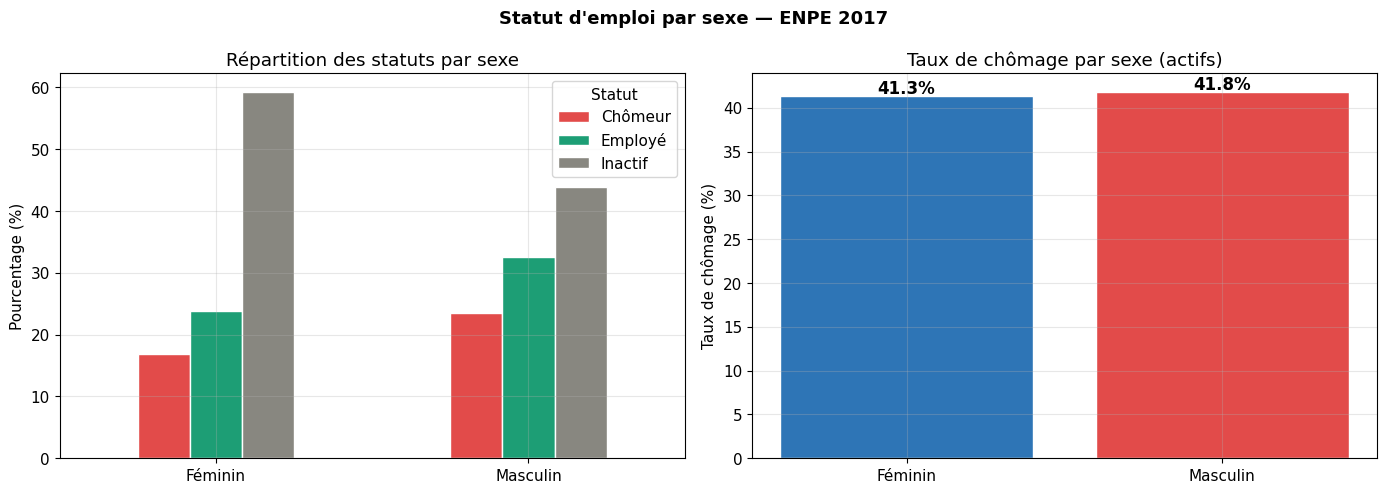

✅ eda3_chomage_sexe.png


In [6]:
SEXE = {1: "Masculin", 2: "Féminin"}
df_eda["sexe"] = df_eda["V_1_204_i"].map(SEXE)

# Recréer df_actifs avec la colonne sexe
df_actifs = df_eda[df_eda["statut"].isin(["Chômeur", "Employé"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Statut d'emploi par sexe — ENPE 2017",
             fontsize=13, fontweight="bold")

# Graphique 1 : Répartition des statuts par sexe
cross = pd.crosstab(df_eda["sexe"], df_eda["statut"], normalize="index") * 100
cross[["Chômeur", "Employé", "Inactif"]].plot(
    kind="bar", ax=axes[0],
    color=[COLORS["Chômeur"], COLORS["Employé"], COLORS["Inactif"]],
    edgecolor="white"
)
axes[0].set_title("Répartition des statuts par sexe")
axes[0].set_ylabel("Pourcentage (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Statut")

# Graphique 2 : Taux de chômage Homme vs Femme
taux_sexe = df_actifs.groupby("sexe").apply(
    lambda x: (x["statut"] == "Chômeur").sum() / len(x) * 100
)
bars = axes[1].bar(taux_sexe.index, taux_sexe.values,
                   color=["#2E75B6", "#E24B4A"], edgecolor="white")
axes[1].set_title("Taux de chômage par sexe (actifs)")
axes[1].set_ylabel("Taux de chômage (%)")
for bar, val in zip(bars, taux_sexe.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("eda3_chomage_sexe.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ eda3_chomage_sexe.png")

---
## 6. Le Paradoxe du Diplôme — Chômage par Niveau d'Instruction

L'un des phénomènes les plus documentés en Tunisie est le **paradoxe du diplôme** : contrairement à ce qu'on attendrait, le taux de chômage *augmente* avec le niveau d'études. Ce paradoxe s'explique par :
- Une inadéquation entre les formations universitaires et les besoins du marché
- Une préférence des diplômés pour le secteur public (saturation)
- Un refus d'accepter des emplois sous-qualifiés

**Codes V_1_225_i :** `1=Sans diplôme`, `2=Enseignement de base`, `3=Secondaire`, `4=Supérieur`

> Ce graphique constitue la **justification centrale** de notre projet ML.


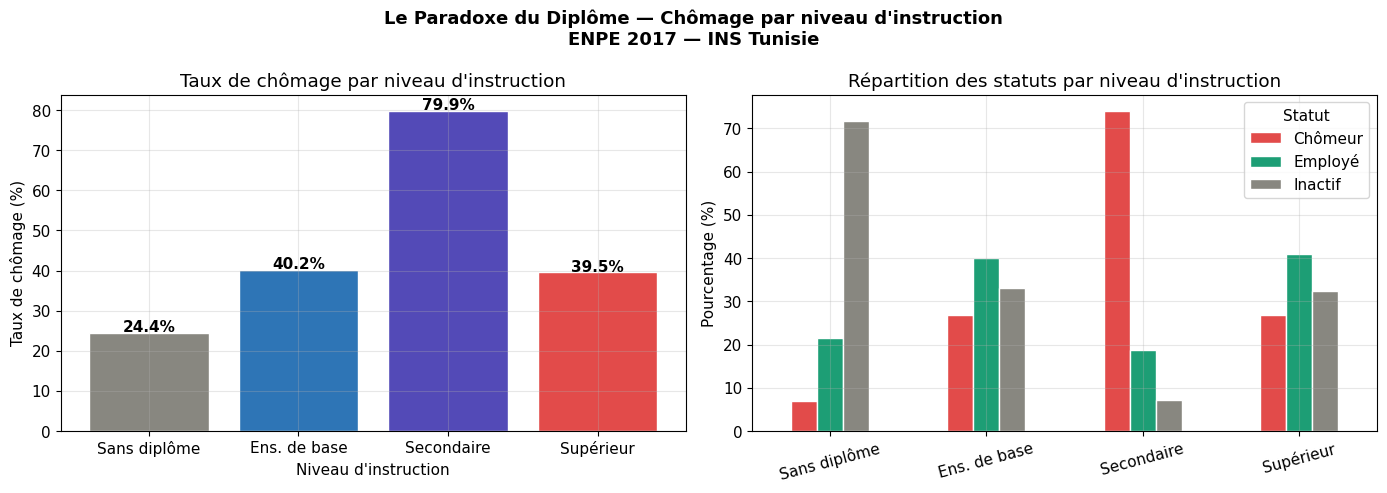

✅ eda4_chomage_niveau_etudes.png


In [7]:
NIV = {1: "Sans diplôme", 2: "Ens. de base", 3: "Secondaire", 4: "Supérieur"}
df_eda["niveau"] = df_eda["V_1_225_i"].map(NIV)
df_actifs2 = df_eda[df_eda["statut"].isin(["Chômeur", "Employé"])].copy()
df_actifs2["niveau"] = df_actifs2["V_1_225_i"].map(NIV)

ordre_niv = ["Sans diplôme", "Ens. de base", "Secondaire", "Supérieur"]
taux_niv = df_actifs2.groupby("niveau").apply(
    lambda x: (x["statut"] == "Chômeur").sum() / len(x) * 100
).reindex(ordre_niv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Le Paradoxe du Diplôme — Chômage par niveau d'instruction\nENPE 2017 — INS Tunisie",
             fontsize=13, fontweight="bold")

# Taux de chômage par niveau
couleurs_niv = ["#888780", "#2E75B6", "#534AB7", "#E24B4A"]
bars = axes[0].bar(ordre_niv, taux_niv.values,
                   color=couleurs_niv, edgecolor="white")
axes[0].set_title("Taux de chômage par niveau d'instruction")
axes[0].set_ylabel("Taux de chômage (%)")
axes[0].set_xlabel("Niveau d'instruction")
for bar, val in zip(bars, taux_niv.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

# Répartition des statuts par niveau
cross_niv = pd.crosstab(df_eda["niveau"], df_eda["statut"], normalize="index") * 100
cross_niv = cross_niv.reindex(ordre_niv)
cross_niv[["Chômeur", "Employé", "Inactif"]].plot(
    kind="bar", ax=axes[1],
    color=[COLORS["Chômeur"], COLORS["Employé"], COLORS["Inactif"]],
    edgecolor="white"
)
axes[1].set_title("Répartition des statuts par niveau d'instruction")
axes[1].set_ylabel("Pourcentage (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Statut")

plt.tight_layout()
plt.savefig("eda4_chomage_niveau_etudes.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ eda4_chomage_niveau_etudes.png")


---
## 7. Distribution de l'Âge par Statut d'Emploi

L'âge est une variable continue importante pour prédire le statut d'emploi. On s'attend à ce que :
- Les **chômeurs** soient en moyenne plus **jeunes** (primo-demandeurs d'emploi)
- Les **employés** aient un âge moyen plus élevé (expérience professionnelle acquise)
- Les **inactifs** soient bimodaux (jeunes étudiants + personnes âgées retraitées)

> **Note :** Le dataset contient des individus d'âge 0 (erreurs de saisie). Ils seront filtrés en Phase 3 avec le seuil `âge ≥ 15`.


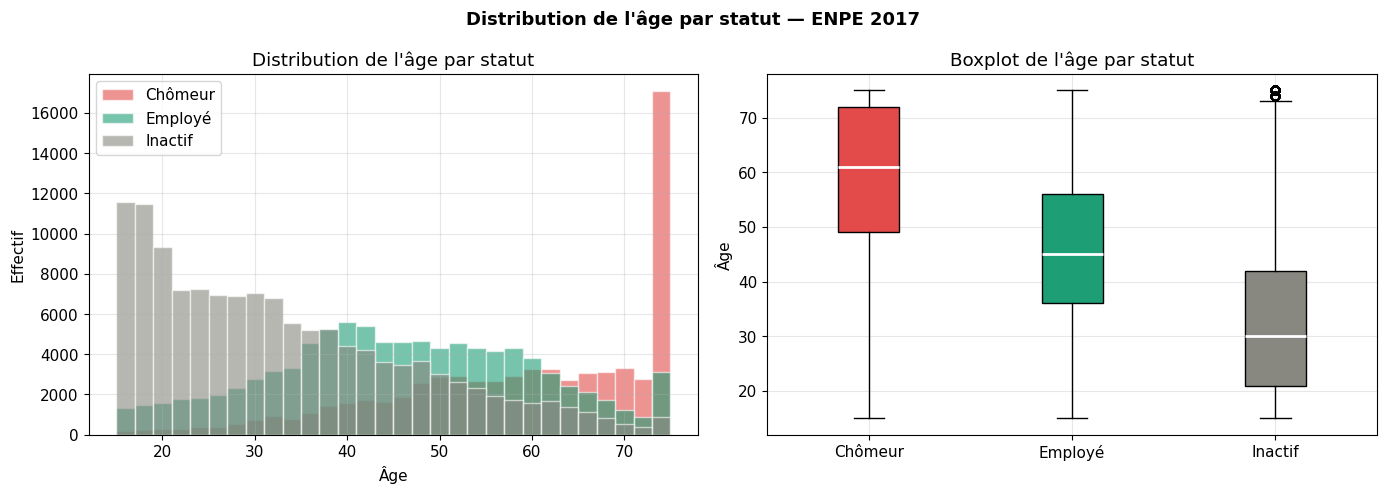


Âge moyen par statut :
  Chômeur      : 58.8 ans
  Employé      : 45.4 ans
  Inactif      : 32.7 ans
✅ eda5_age_statut.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de l'âge par statut — ENPE 2017",
             fontsize=13, fontweight="bold")

# Histogramme superposé
for statut, color in COLORS.items():
    subset = df_eda[df_eda["statut"] == statut]["V_210tr"]
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=statut, edgecolor="white")
axes[0].set_title("Distribution de l'âge par statut")
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Effectif")
axes[0].legend()

# Boxplot
data_box  = [df_eda[df_eda["statut"] == s]["V_210tr"].values
             for s in ["Chômeur", "Employé", "Inactif"]]
bp = axes[1].boxplot(data_box, patch_artist=True,
                     medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(bp["boxes"],
                        [COLORS["Chômeur"], COLORS["Employé"], COLORS["Inactif"]]):
    patch.set_facecolor(color)
axes[1].set_xticklabels(["Chômeur", "Employé", "Inactif"])
axes[1].set_title("Boxplot de l'âge par statut")
axes[1].set_ylabel("Âge")

plt.tight_layout()
plt.savefig("eda5_age_statut.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nÂge moyen par statut :")
for statut in ["Chômeur", "Employé", "Inactif"]:
    moy = df_eda[df_eda["statut"] == statut]["V_210tr"].mean()
    print(f"  {statut:<12} : {moy:.1f} ans")
print("✅ eda5_age_statut.png")


---
## 8. Analyse Territoriale — Régions Côtières vs Intérieures

L'analyse territoriale est l'une des contributions originales de ce projet. Nous distinguons deux groupes de gouvernorats :

| Groupe | Gouvernorats |
|---|---|
| **Côtier** | Tunis, Ariana, Ben Arous, Manouba, Nabeul, Bizerte, Sousse, Monastir, Mahdia, Sfax, Gabès, Médenine |
| **Intérieur** | Kasserine, Gafsa, Sidi Bouzid, Kef, Siliana, Béja, Kairouan, Jendouba, Zaghouan, Tataouine, Tozeur, Kébili |

**Hypothèse testée :** À niveau d'instruction égal, un diplômé de l'intérieur a-t-il un risque de chômage plus élevé qu'un diplômé côtier ?


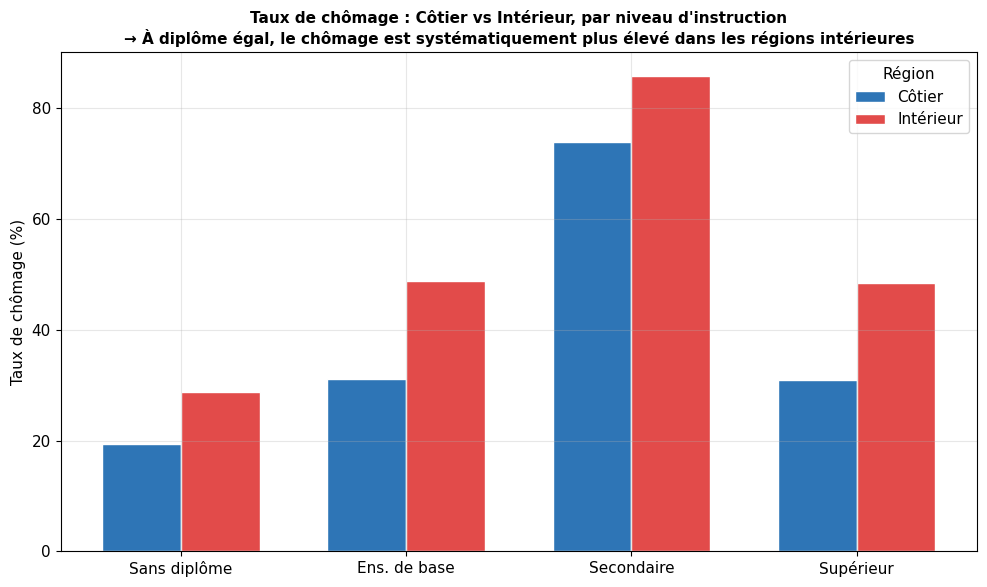

✅ eda6_paradoxe_territorial.png


In [9]:
INTERIEUR = ["Kasserine", "Gafsa", "Sidi Bouzid", "Kef", "Siliana",
             "Béja", "Kairouan", "Jendouba", "Zaghouan", "Tataouine",
             "Tozeur", "Kébili"]

df_eda["region"] = df_eda["gouvernorat"].apply(
    lambda g: "Intérieur" if g in INTERIEUR else "Côtier"
)

# Taux de chômage par région ET niveau d'études
df_actifs3 = df_eda[df_eda["statut"].isin(["Chômeur", "Employé"])].copy()
df_actifs3["region"] = df_actifs3["gouvernorat"].apply(
    lambda g: "Intérieur" if g in INTERIEUR else "Côtier"
)
df_actifs3["niveau"] = df_actifs3["V_1_225_i"].map(NIV)

pivot = df_actifs3.groupby(["region", "niveau"]).apply(
    lambda x: (x["statut"] == "Chômeur").sum() / len(x) * 100
).unstack(level=0)
pivot = pivot.reindex(["Sans diplôme", "Ens. de base", "Secondaire", "Supérieur"])

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pivot.index))
w = 0.35
ax.bar(x - w/2, pivot["Côtier"],  width=w, color="#2E75B6",
       edgecolor="white", label="Côtier")
ax.bar(x + w/2, pivot["Intérieur"], width=w, color="#E24B4A",
       edgecolor="white", label="Intérieur")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_title("Taux de chômage : Côtier vs Intérieur, par niveau d'instruction\n"
             "→ À diplôme égal, le chômage est systématiquement plus élevé dans les régions intérieures",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Taux de chômage (%)")
ax.legend(title="Région")
plt.tight_layout()
plt.savefig("eda6_paradoxe_territorial.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ eda6_paradoxe_territorial.png")


---
## 9. Analyse du Milieu de Résidence — Urbain vs Rural

Le milieu de résidence (urbain/rural) est une autre dimension importante du marché du travail tunisien. Les zones rurales ont généralement moins d'opportunités d'emploi qualifié, ce qui crée un gradient urbain-rural dans les taux de chômage.

**Codes V_9_11_1 :** `1 = Communal (urbain)`, `2 = Non communal (rural)`


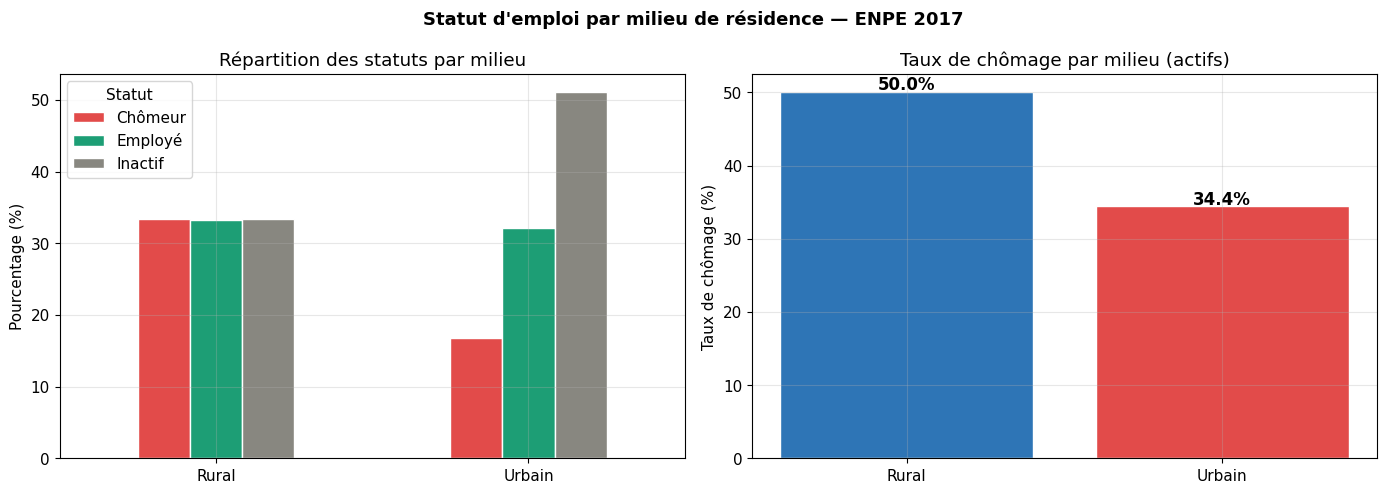

✅ eda7_chomage_milieu.png


In [10]:
MILIEU = {1: "Urbain", 2: "Rural"}
df_eda["milieu"] = df_eda["V_9_11_1"].map(MILIEU)
df_actifs4 = df_actifs.copy()
df_actifs4["milieu"] = df_actifs4["V_9_11_1"].map(MILIEU)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Statut d'emploi par milieu de résidence — ENPE 2017",
             fontsize=13, fontweight="bold")

# Répartition des statuts par milieu
cross_mil = pd.crosstab(df_eda["milieu"], df_eda["statut"], normalize="index") * 100
cross_mil[["Chômeur", "Employé", "Inactif"]].plot(
    kind="bar", ax=axes[0],
    color=[COLORS["Chômeur"], COLORS["Employé"], COLORS["Inactif"]],
    edgecolor="white"
)
axes[0].set_title("Répartition des statuts par milieu")
axes[0].set_ylabel("Pourcentage (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Statut")

# Taux de chômage par milieu
taux_mil = df_actifs4.groupby("milieu").apply(
    lambda x: (x["statut"] == "Chômeur").sum() / len(x) * 100
)
bars = axes[1].bar(taux_mil.index, taux_mil.values,
                   color=["#2E75B6", "#E24B4A"], edgecolor="white")
axes[1].set_title("Taux de chômage par milieu (actifs)")
axes[1].set_ylabel("Taux de chômage (%)")
for bar, val in zip(bars, taux_mil.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("eda7_chomage_milieu.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ eda7_chomage_milieu.png")


---
## 10. Matrice de Corrélation

La matrice de corrélation mesure les relations linéaires entre les variables numériques. Elle permet d'identifier :
- Les **variables fortement corrélées** entre elles (redondance → à gérer en Feature Selection)
- Les **variables corrélées avec la cible** (prédicteurs potentiels)

> **Interprétation :** Une corrélation proche de +1 ou -1 indique une forte relation linéaire. Proche de 0 = relation faible ou non-linéaire.


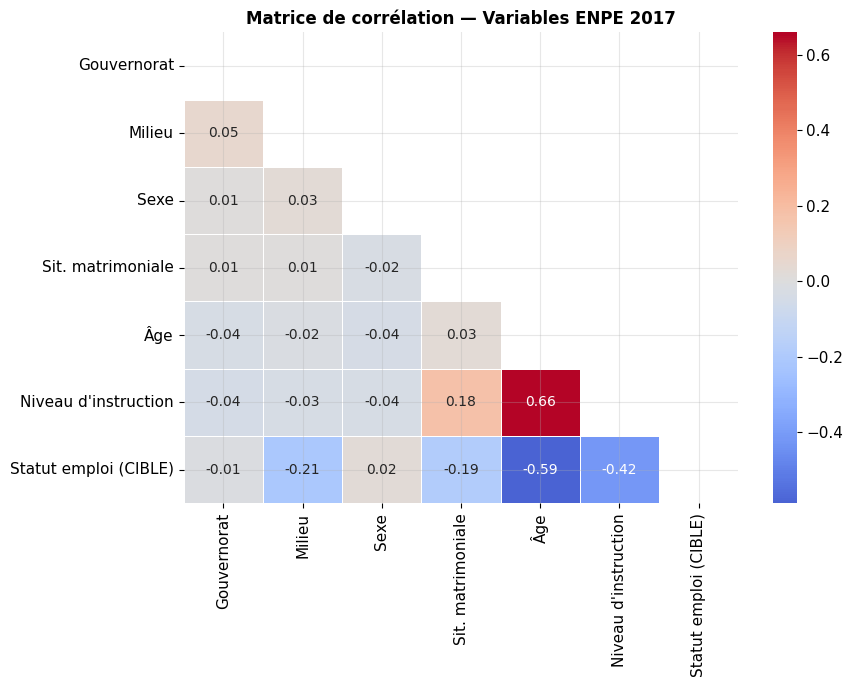

✅ eda8_correlation.png


In [11]:
cols_corr = ["V_9_10_i", "V_9_11_1", "V_1_204_i", "V_1_205_i",
             "V_210tr", "V_1_225_i", "V_0_244_i"]

noms_corr = {
    "V_9_10_i":  "Gouvernorat",
    "V_9_11_1":  "Milieu",
    "V_1_204_i": "Sexe",
    "V_1_205_i": "Sit. matrimoniale",
    "V_210tr":   "Âge",
    "V_1_225_i": "Niveau d'instruction",
    "V_0_244_i": "Statut emploi (CIBLE)"
}

df_corr = df_eda[cols_corr].dropna().rename(columns=noms_corr)
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, mask=mask, ax=ax,
            annot_kws={"size": 10},
            linewidths=0.5, linecolor="white")
ax.set_title("Matrice de corrélation — Variables ENPE 2017",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eda8_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ eda8_correlation.png")


---
## 11. Résumé de la Phase 2

Bilan des observations et conclusions de l'analyse exploratoire, qui orienteront les choix de la Phase 3 (Preprocessing & Feature Engineering).


In [12]:
print("\n" + "=" * 60)
print("  RÉSUMÉ PHASE 2 — ANALYSE EXPLORATOIRE (EDA)")
print("=" * 60)
print(f"""
  Dataset analysé : {len(df_eda):,} individus (après filtrage)

  ── Observations clés ──

  1. DÉSÉQUILIBRE DES CLASSES
     Inactif  ~43%  |  Chômeur ~36%  |  Employé ~21%
     → SMOTE obligatoire en Phase 3

  2. PARADOXE DU DIPLÔME
     Le taux de chômage augmente avec le niveau d'études
     → Variable V_1_225_i sera une feature clé du modèle

  3. DISPARITÉS RÉGIONALES
     Régions intérieures = chômage systématiquement plus élevé
     → Feature engineering : region_interieure (binaire)

  4. ASYMÉTRIE DE GENRE
     Femmes : taux d'inactivité très élevé + chômage > hommes
     → Feature engineering : femme_region_int (interaction)

  5. FACTEUR ÂGE
     Chômeurs plus jeunes en moyenne
     → Feature engineering : groupe_age (catégoriel)

  ── Graphiques générés (8) ──""")

graphiques = [
    "eda1_distribution_cible.png",
    "eda2_chomage_gouvernorat.png",
    "eda3_chomage_sexe.png",
    "eda4_chomage_niveau_etudes.png",
    "eda5_age_statut.png",
    "eda6_paradoxe_territorial.png",
    "eda7_chomage_milieu.png",
    "eda8_correlation.png",
]
for g in graphiques:
    print(f"    ✅ {g}")

print("\n" + "=" * 60)
print("  ✅ Phase 2 terminée → Prochaine étape : Phase 3 (Preprocessing)")
print("=" * 60)



  RÉSUMÉ PHASE 2 — ANALYSE EXPLORATOIRE (EDA)

  Dataset analysé : 295,411 individus (après filtrage)

  ── Observations clés ──

  1. DÉSÉQUILIBRE DES CLASSES
     Inactif  ~43%  |  Chômeur ~36%  |  Employé ~21%
     → SMOTE obligatoire en Phase 3

  2. PARADOXE DU DIPLÔME
     Le taux de chômage augmente avec le niveau d'études
     → Variable V_1_225_i sera une feature clé du modèle

  3. DISPARITÉS RÉGIONALES
     Régions intérieures = chômage systématiquement plus élevé
     → Feature engineering : region_interieure (binaire)

  4. ASYMÉTRIE DE GENRE
     Femmes : taux d'inactivité très élevé + chômage > hommes
     → Feature engineering : femme_region_int (interaction)

  5. FACTEUR ÂGE
     Chômeurs plus jeunes en moyenne
     → Feature engineering : groupe_age (catégoriel)

  ── Graphiques générés (8) ──
    ✅ eda1_distribution_cible.png
    ✅ eda2_chomage_gouvernorat.png
    ✅ eda3_chomage_sexe.png
    ✅ eda4_chomage_niveau_etudes.png
    ✅ eda5_age_statut.png
    ✅ eda6_para